In [16]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

print(f"TF Version: {tf.__version__}")

DATA_PATH = "/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv"
BERT_ENCODER_PATH = "/kaggle/input/models/tensorflow/bert/tensorflow2/bert-en-uncased-l-12-h-768-a-12/2"
BERT_PREPROCESS_PATH = "/kaggle/input/models/tensorflow/bert/tensorflow2/en-uncased-preprocess/3"

TF Version: 2.19.0


In [3]:
df = pd.read_csv(DATA_PATH)

import re
#Removes Punctuations
def remove_punctuations(data):
    punct_tag=re.compile(r'[^\w\s]')
    data=punct_tag.sub(r'',data)
    return data

#Removes HTML syntaxes
def remove_html(data):
    html_tag=re.compile(r'<.*?>')
    data=html_tag.sub(r'',data)
    return data

#Removes URL data
def remove_url(data):
    url_clean= re.compile(r"https://\S+|www\.\S+")
    data=url_clean.sub(r'',data)
    return data

#Removes Emojis
def remove_emoji(data):
    emoji_clean= re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    data=emoji_clean.sub(r'',data)
    url_clean= re.compile(r"https://\S+|www\.\S+")
    data=url_clean.sub(r'',data)
    return data

df['review']=df['review'].apply(lambda z: remove_punctuations(z))

df['review']=df['review'].apply(lambda z: remove_html(z))
df['review']=df['review'].apply(lambda z: remove_url(z))
df['review']=df['review'].apply(lambda z: remove_emoji(z))

def remove_abb(data):
    if pd.isna(data) or data is None:
        return ""
    data = re.sub(r"he's", "he is", data)
    data = re.sub(r"there's", "there is", data)
    data = re.sub(r"We're", "We are", data)
    data = re.sub(r"That's", "That is", data)
    data = re.sub(r"won't", "will not", data)
    data = re.sub(r"they're", "they are", data)
    data = re.sub(r"Can't", "Cannot", data)
    data = re.sub(r"wasn't", "was not", data)
    data = re.sub(r"don\x89Ûªt", "do not", data)
    data= re.sub(r"aren't", "are not", data)
    data = re.sub(r"isn't", "is not", data)
    data = re.sub(r"What's", "What is", data)
    data = re.sub(r"haven't", "have not", data)
    data = re.sub(r"hasn't", "has not", data)
    data = re.sub(r"There's", "There is", data)
    data = re.sub(r"He's", "He is", data)
    data = re.sub(r"It's", "It is", data)
    data = re.sub(r"You're", "You are", data)
    data = re.sub(r"I'M", "I am", data)
    data = re.sub(r"shouldn't", "should not", data)
    data = re.sub(r"wouldn't", "would not", data)
    data = re.sub(r"i'm", "I am", data)
    data = re.sub(r"I\x89Ûªm", "I am", data)
    data = re.sub(r"I'm", "I am", data)
    data = re.sub(r"Isn't", "is not", data)
    data = re.sub(r"Here's", "Here is", data)
    data = re.sub(r"you've", "you have", data)
    data = re.sub(r"you\x89Ûªve", "you have", data)
    data = re.sub(r"we're", "we are", data)
    data = re.sub(r"what's", "what is", data)
    data = re.sub(r"couldn't", "could not", data)
    data = re.sub(r"we've", "we have", data)
    data = re.sub(r"it\x89Ûªs", "it is", data)
    data = re.sub(r"doesn\x89Ûªt", "does not", data)
    data = re.sub(r"It\x89Ûªs", "It is", data)
    data = re.sub(r"Here\x89Ûªs", "Here is", data)
    data = re.sub(r"who's", "who is", data)
    data = re.sub(r"I\x89Ûªve", "I have", data)
    data = re.sub(r"y'all", "you all", data)
    data = re.sub(r"can\x89Ûªt", "cannot", data)
    data = re.sub(r"would've", "would have", data)
    data = re.sub(r"it'll", "it will", data)
    data = re.sub(r"we'll", "we will", data)
    data = re.sub(r"wouldn\x89Ûªt", "would not", data)
    data = re.sub(r"We've", "We have", data)
    data = re.sub(r"he'll", "he will", data)
    data = re.sub(r"Y'all", "You all", data)
    data = re.sub(r"Weren't", "Were not", data)
    data = re.sub(r"Didn't", "Did not", data)
    data = re.sub(r"they'll", "they will", data)
    data = re.sub(r"they'd", "they would", data)
    data = re.sub(r"DON'T", "DO NOT", data)
    data = re.sub(r"That\x89Ûªs", "That is", data)
    data = re.sub(r"they've", "they have", data)
    data = re.sub(r"i'd", "I would", data)
    data = re.sub(r"should've", "should have", data)
    data = re.sub(r"You\x89Ûªre", "You are", data)
    data = re.sub(r"where's", "where is", data)
    data = re.sub(r"Don\x89Ûªt", "Do not", data)
    data = re.sub(r"we'd", "we would", data)
    data = re.sub(r"i'll", "I will", data)
    data = re.sub(r"weren't", "were not", data)
    data = re.sub(r"They're", "They are", data)
    data = re.sub(r"Can\x89Ûªt", "Cannot", data)
    data = re.sub(r"you\x89Ûªll", "you will", data)
    data = re.sub(r"I\x89Ûªd", "I would", data)
    data = re.sub(r"let's", "let us", data)
    data = re.sub(r"it's", "it is", data)
    data = re.sub(r"can't", "cannot", data)
    data = re.sub(r"don't", "do not", data)
    data = re.sub(r"you're", "you are", data)
    data = re.sub(r"i've", "I have", data)
    data = re.sub(r"that's", "that is", data)
    data = re.sub(r"i'll", "I will", data)
    data = re.sub(r"doesn't", "does not",data)
    data = re.sub(r"i'd", "I would", data)
    data = re.sub(r"didn't", "did not", data)
    data = re.sub(r"ain't", "am not", data)
    data = re.sub(r"you'll", "you will", data)
    data = re.sub(r"I've", "I have", data)
    data = re.sub(r"Don't", "do not", data)
    data = re.sub(r"I'll", "I will", data)
    data = re.sub(r"I'd", "I would", data)
    data = re.sub(r"Let's", "Let us", data)
    data = re.sub(r"you'd", "You would", data)
    data = re.sub(r"It's", "It is", data)
    data = re.sub(r"Ain't", "am not", data)
    data = re.sub(r"Haven't", "Have not", data)
    data = re.sub(r"Could've", "Could have", data)
    data = re.sub(r"youve", "you have", data)  
    data = re.sub(r"donå«t", "do not", data)
    return data
df['review']=df['review'].apply(lambda z: remove_abb(z))

df['label'] = df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)

df.dropna(subset=['review', 'label'], inplace=True)

print(df.shape)
print(df.head())
print(df['sentiment'].value_counts())

(50000, 3)
                                              review sentiment  label
0  One of the other reviewers has mentioned that ...  positive      1
1  A wonderful little production br br The filmin...  positive      1
2  I thought this was a wonderful way to spend ti...  positive      1
3  Basically theres a family where a little boy J...  negative      0
4  Petter Matteis Love in the Time of Money is a ...  positive      1
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [4]:
texts = df['review'].values
labels = df['label'].values.astype(np.float32)

x_train, x_val, y_train, y_val = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Train: {len(x_train)}, Val: {len(x_val)}")

Train: 40000, Val: 10000


In [6]:
class BertPreprocessorLayer(layers.Layer):
    def __init__(self, handle, **kwargs):
        super().__init__(**kwargs)
        self.preprocessor = hub.load(handle)
    def call(self, inputs):
        return self.preprocessor(inputs)

class BertEncoderLayer(layers.Layer):
    def __init__(self, handle, trainable=True, **kwargs):
        super().__init__(**kwargs)
        self.encoder = hub.load(handle)
        self._trainable = trainable
    @property
    def trainable(self):
        return self._trainable
    def call(self, inputs):
        return self.encoder(inputs)

preprocessor_layer = BertPreprocessorLayer(BERT_PREPROCESS_PATH, name="preprocessing")
encoder_layer = BertEncoderLayer(BERT_ENCODER_PATH, trainable=True, name="bert_encoder")

def build_lstm_cnn_model():
    # Input
    text_input = layers.Input(shape=(), dtype=tf.string, name='text')
    
    # BERT
    preprocessed = preprocessor_layer(text_input)
    encoder_outputs = encoder_layer(preprocessed)
    sequence_output = encoder_outputs['sequence_output'] # [batch, seq_len, 768]
    
    # BiLSTM (128 units)
    net = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(sequence_output)
    
    # Conv1D Block 1 (Filter 128, Kernel 7)
    net = layers.Conv1D(filters=128, kernel_size=7, activation='relu', padding='same')(net)
    net = layers.MaxPooling1D()(net)
    
    # Conv1D Block 2 (Filter 256, Kernel 5)
    net = layers.Conv1D(filters=256, kernel_size=5, activation='relu', padding='same')(net)
    net = layers.MaxPooling1D()(net)
    
    # Conv1D Block 3 (Filter 512, Kernel 3)
    net = layers.Conv1D(filters=512, kernel_size=3, activation='relu', padding='same')(net)
    net = layers.MaxPooling1D()(net)
    
    # Classifier
    net = layers.Flatten()(net)
    net = layers.Dense(128, activation='relu')(net)
    net = layers.Dropout(0.5)(net)
    output = layers.Dense(1, activation='sigmoid', name='classifier')(net)
    
    return keras.Model(inputs=text_input, outputs=output)

model = build_lstm_cnn_model()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text (InputLayer)   │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preprocessing       │ [(None, 128),     │          0 │ text[0][0]        │
│ (BertPreprocessorL… │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bert_encoder        │ [(None, 768),     │          0 │ preprocessing[0]… │
│ (BertEncoderLayer)  │ (None, 128, 768), │            │ preprocessing[0]… │
│                     │ (None, 128, 768), │            │ preprocessing[0]… │
│                     │ (None, 128, 768), │            │                   │
│                     │ (None, 128, 768), │            │                   │
│                     │ (None, 128, 768), │            │                   │
│                     │ (None, 128, 768), │            │                   │
│                     │ (None, 128, 768), │            │                   │
│                     │ (None, 128, 768), │            │                   │
│                     │ (None, 128, 768), │            │                   │
│                     │ (None, 128, 768), │            │                   │
│                     │ (None, 128, 768), │            │                   │
│                     │ (None, 128, 768), │            │                   │
│                     │ (None, 768),      │            │                   │
│                     │ (None, 128, 768)] │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128, 256)  │    918,528 │ bert_encoder[0][… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 128, 128)  │    229,504 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 64, 128)   │          0 │ conv1d_3[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 64, 256)   │    164,096 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 32, 256)   │          0 │ conv1d_4[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 32, 512)   │    393,728 │ max_pooling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_5     │ (None, 16, 512)   │          0 │ conv1d_5[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 8192)      │          0 │ max_pooling1d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │  1,048,704 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier (Dense)  │ (None, 1)         │        129 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,754,689 (10.51 MB)

 Trainable params: 2,754,689 (10.51 MB)

 Non-trainable params: 0 (0.00 B)

Start Fine-tuning...
Epoch 1/3
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7372 - loss: 0.5017
Epoch 1: val_accuracy improved from None to 0.82290, saving model to /kaggle/working/best_lstm_cnn_finetune.h5



Epoch 1: finished saving model to /kaggle/working/best_lstm_cnn_finetune.h5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10436s 4s/step - accuracy: 0.7914 - loss: 0.4371 - val_accuracy: 0.8229 - val_loss: 0.3838
Epoch 2/3
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8338 - loss: 0.3737
Epoch 2: val_accuracy improved from 0.82290 to 0.84690, saving model to /kaggle/working/best_lstm_cnn_finetune.h5



Epoch 2: finished saving model to /kaggle/working/best_lstm_cnn_finetune.h5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10489s 4s/step - accuracy: 0.8379 - loss: 0.3677 - val_accuracy: 0.8469 - val_loss: 0.3407
Epoch 3/3
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8498 - loss: 0.3424
Epoch 3: val_accuracy improved from 0.84690 to 0.85450, saving model to /kaggle/working/best_lstm_cnn_finetune.h5



Epoch 3: finished saving model to /kaggle/working/best_lstm_cnn_finetune.h5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10519s 4s/step - accuracy: 0.8523 - loss: 0.3375 - val_accuracy: 0.8545 - val_loss: 0.3245


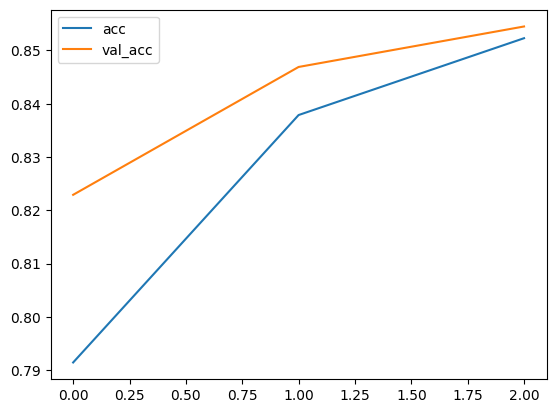

In [7]:
optimizer = keras.optimizers.Adam(learning_rate=2e-5)
loss = keras.losses.BinaryCrossentropy()
metrics = ['accuracy']

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

checkpoint = keras.callbacks.ModelCheckpoint(
    '/kaggle/working/best_lstm_cnn_finetune.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

EPOCHS = 3
BATCH_SIZE = 16 

print("Start Fine-tuning...")
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[checkpoint]
)

plt.plot(history.history['accuracy'], label='acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

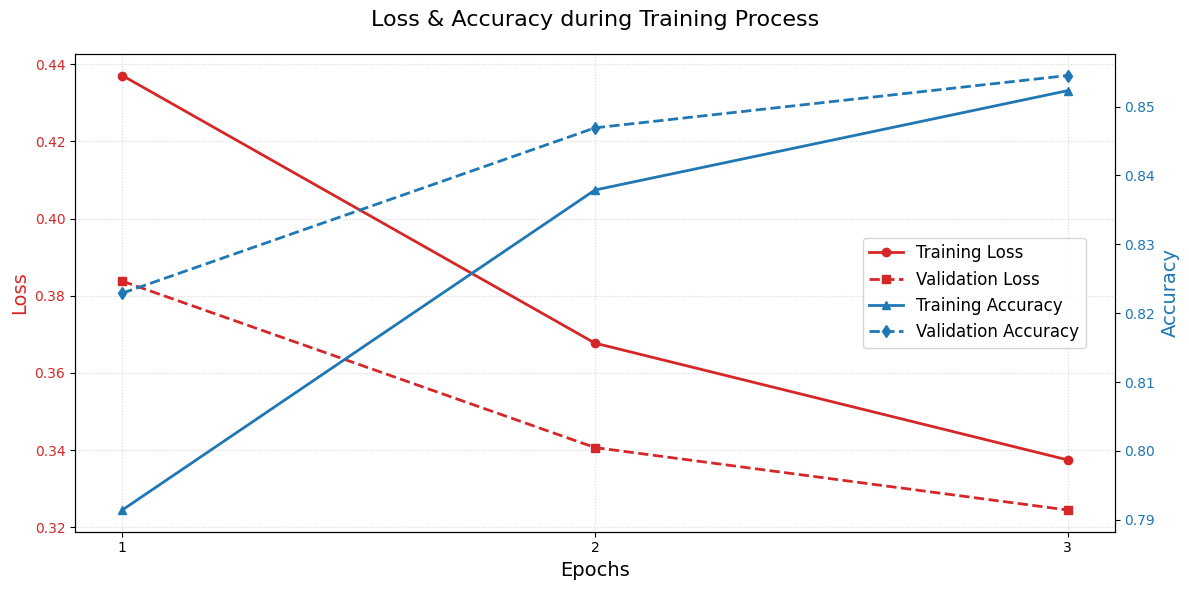

In [11]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

fig, ax1 = plt.subplots(figsize=(12, 6))

color_loss = 'tab:red'
ax1.set_xlabel('Epochs', fontsize=14)
ax1.set_ylabel('Loss', color=color_loss, fontsize=14)
ax1.plot(epochs_range, loss, 'o-', color=color_loss, label='Training Loss', linewidth=2, markersize=6)
ax1.plot(epochs_range, val_loss, 's--', color=color_loss, label='Validation Loss', linewidth=2, markersize=6)
ax1.tick_params(axis='y', labelcolor=color_loss)
ax1.grid(True, linestyle=':', alpha=0.5)

ax2 = ax1.twinx()

color_acc = 'tab:blue'
ax2.set_ylabel('Accuracy', color=color_acc, fontsize=14)
ax2.plot(epochs_range, acc, '^-', color=color_acc, label='Training Accuracy', linewidth=2, markersize=6)
ax2.plot(epochs_range, val_acc, 'd--', color=color_acc, label='Validation Accuracy', linewidth=2, markersize=6)
ax2.tick_params(axis='y', labelcolor=color_acc)

plt.title('Loss & Accuracy during Training Process', fontsize=16, pad=20)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, 
           loc='center right', 
           bbox_to_anchor=(0.98, 0.5), 
           fontsize=12, 
           framealpha=0.8,      
           facecolor='white')   

plt.xticks(ticks=epochs_range, labels=[str(x) for x in epochs_range])

plt.tight_layout()
plt.show()

In [13]:
print("Predicting on Validation Set...")
y_pred_proba = model.predict(x_val, batch_size=32)
y_pred = (y_pred_proba >= 0.5).astype(int).flatten()

Predicting on Validation Set...
313/313 ━━━━━━━━━━━━━━━━━━━━ 2090s 7s/step


NameError: name 'accuracy_score' is not defined


EVALUATION RESULTS
Accuracy:   0.8545
F1 Score:   0.8545
ROC AUC:    0.9357

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.85      0.85      5000
    Positive       0.85      0.86      0.85      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



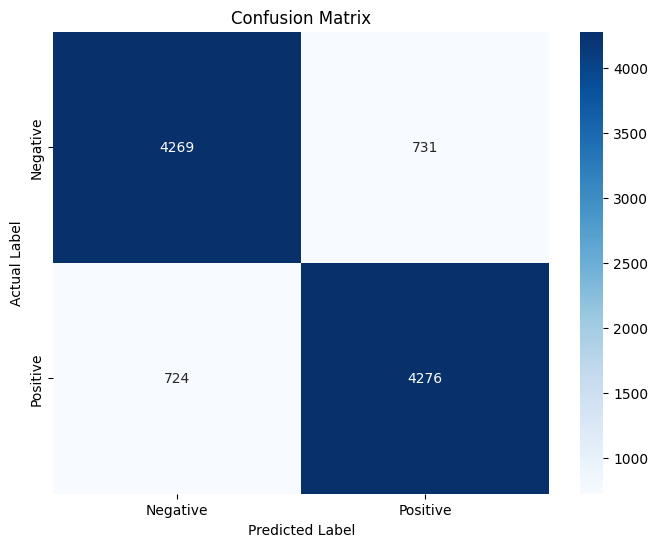


Model saved to: /kaggle/working/final_bert_lstm_cnn_model.keras


In [17]:
acc = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred, average='weighted')
auc = roc_auc_score(y_val, y_pred_proba)

print("\n" + "="*30)
print("EVALUATION RESULTS")
print("="*30)
print(f"Accuracy:   {acc:.4f}")
print(f"F1 Score:   {f1:.4f}")
print(f"ROC AUC:    {auc:.4f}")
print("="*30)
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

MODEL_SAVE_PATH = '/kaggle/working/final_bert_lstm_cnn_model.keras'
model.save(MODEL_SAVE_PATH)
print(f"\nModel saved to: {MODEL_SAVE_PATH}")